# Task 1: Data Analysis and Preparation

The objective of this section is to understand the Airbnb dataset and prepare it
for machine learning. The following steps are performed:

1. Load and inspect the dataset
2. Analyze data types and missing values
3. Remove irrelevant columns
4. Handle missing values
5. Analyze and handle price outliers
6. Perform exploratory data analysis
7. Create useful features
8. Select features for model training
9. Prepare the final dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the Airbnb dataset
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Dataset Shape: (48895, 16)

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:


,Data Type
id,int64
name,str
host_id,int64
host_name,str
neighbourhood_group,str
neighbourhood,str
latitude,float64
longitude,float64
room_type,str
price,int64



Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0].sort_values(
    "Missing Percentage", ascending=False
)

display(missing)

,Missing Values,Missing Percentage
reviews_per_month,10052,20.558339
last_review,10052,20.558339
host_name,21,0.042949
name,16,0.032723


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate IDs:", df["id"].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate IDs: 0


In [7]:
# Convert last_review to datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# Extract useful information from the review date
df["last_review_year"] = df["last_review"].dt.year
df["last_review_month"] = df["last_review"].dt.month

# Create a binary indicator showing whether the listing has received a review
df["has_review"] = df["last_review"].notna().astype(int)

# Drop the original date/text and identifier columns
df.drop(
    columns=["id", "host_id", "name", "host_name", "last_review"],
    inplace=True
)

print("Shape after removing irrelevant columns:", df.shape)
display(df.head())

Shape after removing irrelevant columns: (48895, 14)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,has_review
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,1
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,NaN,NaN,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,2019.0,7.0,1
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2018.0,11.0,1


In [8]:
# A missing reviews_per_month indicates no recorded monthly reviews
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print("Missing values after initial treatment:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values after initial treatment:


last_review_year                  10052
last_review_month                 10052
latitude                              0
longitude                             0
neighbourhood_group                   0
neighbourhood                         0
price                                 0
room_type                             0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
reviews_per_month                     0
availability_365                      0
has_review                            0
dtype: int64

In [9]:
print("Price statistics:")
display(df["price"].describe())

print("\nNumber of zero-price listings:", (df["price"] == 0).sum())

print("\nSelected price percentiles:")
display(
    df["price"].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99])
)

Price statistics:


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Number of zero-price listings: 11

Selected price percentiles:


0.01     30.0
0.25     69.0
0.50    106.0
0.75    175.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

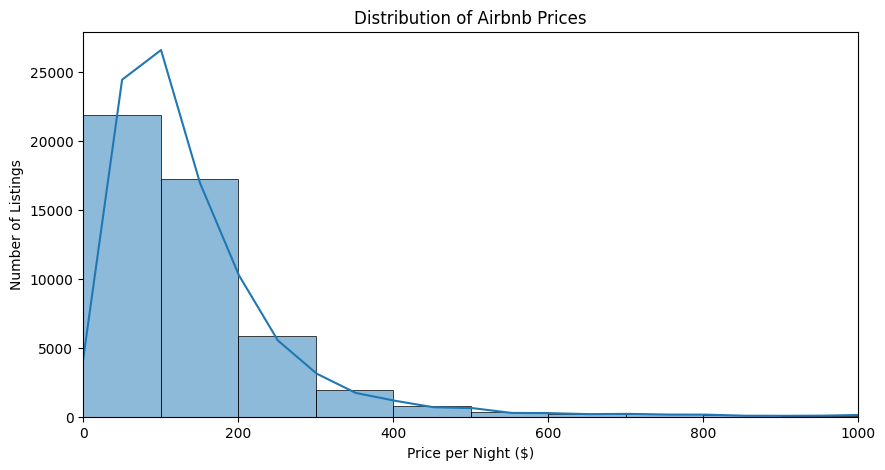

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=100, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.xlim(0, 1000)
plt.show()

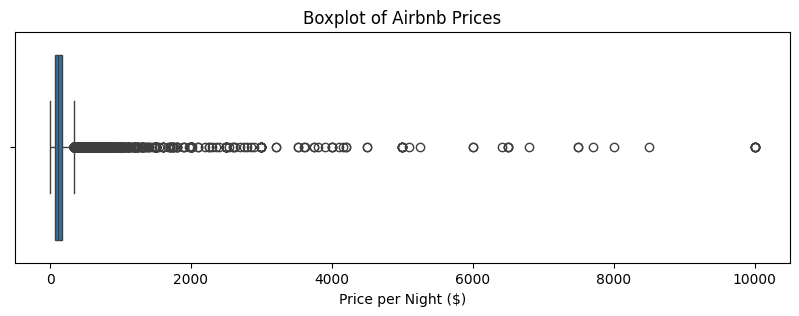

In [11]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price per Night ($)")
plt.show()

In [12]:
# Remove zero-price listings
df = df[df["price"] > 0].copy()

# Calculate 99th percentile
price_upper_limit = df["price"].quantile(0.99)

print("99th percentile price:", price_upper_limit)

# Remove extreme price outliers
df = df[df["price"] <= price_upper_limit].copy()

print("Shape after price outlier treatment:", df.shape)
print("Maximum price after treatment:", df["price"].max())

99th percentile price: 799.0
Shape after price outlier treatment: (48410, 14)
Maximum price after treatment: 799


In [13]:
# Remove zero-price listings
df = df[df["price"] > 0].copy()

# Calculate 99th percentile
price_upper_limit = df["price"].quantile(0.99)

print("99th percentile price:", price_upper_limit)

# Remove extreme price outliers
df = df[df["price"] <= price_upper_limit].copy()

print("Shape after price outlier treatment:", df.shape)
print("Maximum price after treatment:", df["price"].max())

99th percentile price: 550.0
Shape after price outlier treatment: (47949, 14)
Maximum price after treatment: 550


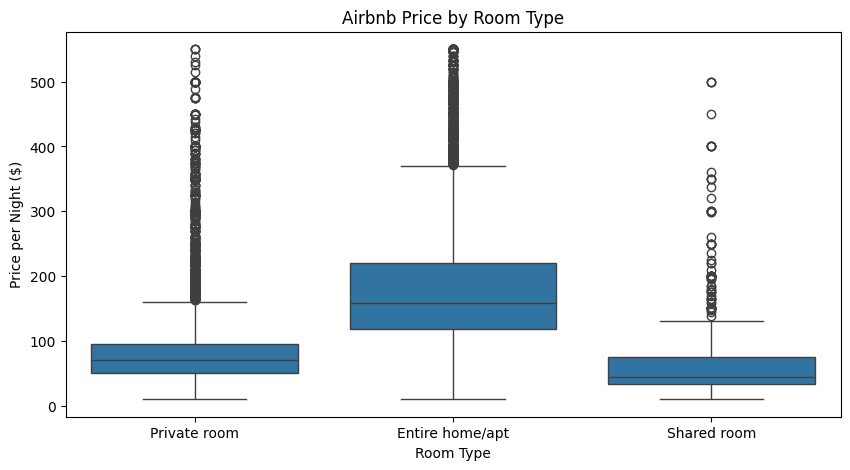

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="room_type", y="price")
plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price per Night ($)")
plt.show()

In [15]:
room_price = (
    df.groupby("room_type")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

display(room_price)

,mean,median,count
room_type,,,
Entire home/apt,181.227007,159.0,24616
Private room,81.965424,70.0,22183
Shared room,63.628696,45.0,1150


In [16]:
room_price = (
    df.groupby("room_type")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

display(room_price)

,mean,median,count
room_type,,,
Entire home/apt,181.227007,159.0,24616
Private room,81.965424,70.0,22183
Shared room,63.628696,45.0,1150


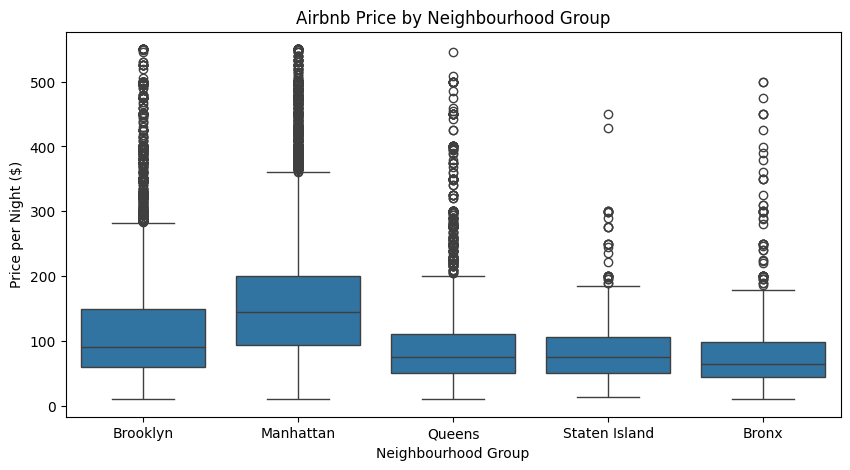

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="neighbourhood_group", y="price")
plt.title("Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price per Night ($)")
plt.show()

In [18]:
neighbourhood_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

display(neighbourhood_price)

,mean,median,count
neighbourhood_group,,,
Manhattan,164.592644,145.0,20962
Brooklyn,113.367776,90.0,19898
Queens,93.004788,75.0,5639
Staten Island,91.144414,75.0,367
Bronx,81.818098,65.0,1083


In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns

correlation = df[numeric_cols].corr()["price"].sort_values(ascending=False)

display(correlation)

price                             1.000000
calculated_host_listings_count    0.162605
availability_365                  0.097584
latitude                          0.068148
minimum_nights                    0.028259
last_review_month                 0.019066
last_review_year                  0.013911
reviews_per_month                -0.048045
number_of_reviews                -0.048884
has_review                       -0.079525
longitude                        -0.290894
Name: price, dtype: float64

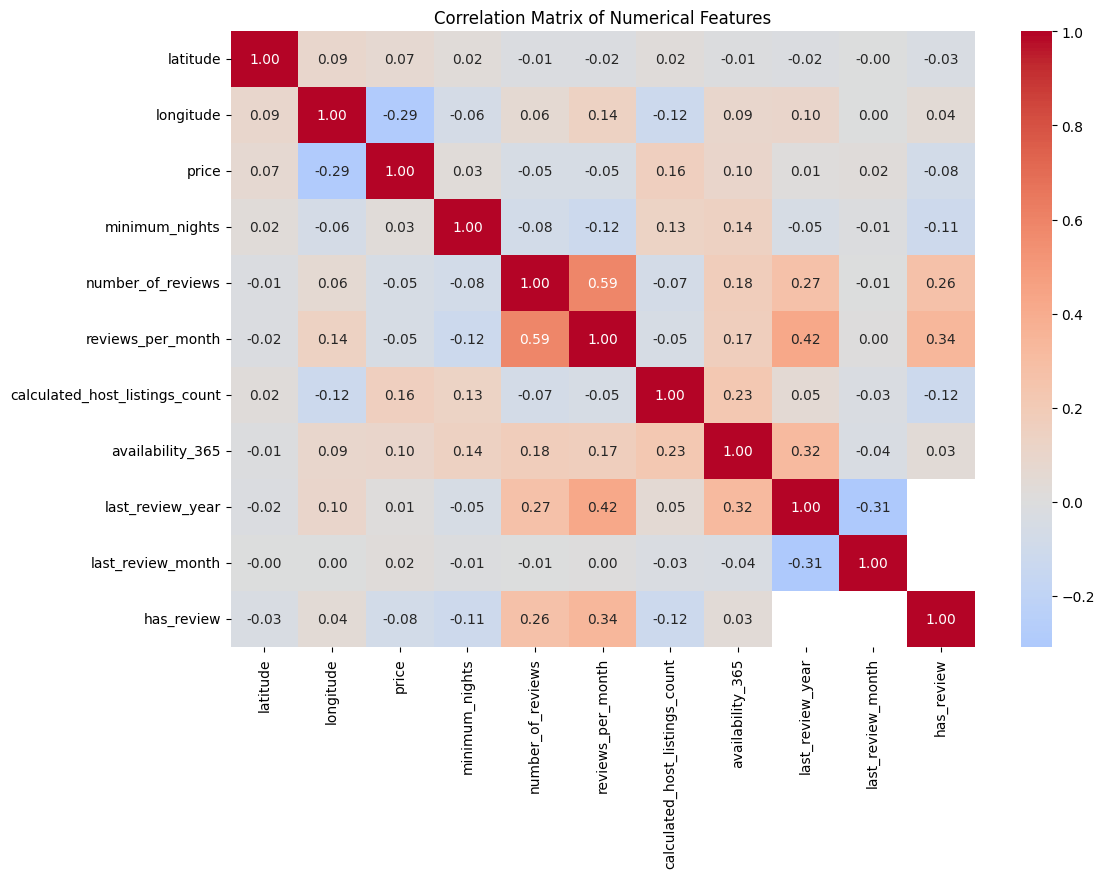

In [20]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [21]:
print("Final columns:")
print(df.columns.tolist())

print("\nFinal shape:", df.shape)

display(df.head())

Final columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'last_review_year', 'last_review_month', 'has_review']

Final shape: (47949, 14)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,has_review
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,2018.0,10.0,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,2019.0,5.0,1
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,NaN,NaN,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,2019.0,7.0,1
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,2018.0,11.0,1


In [22]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nNumerical features:")
print(X.select_dtypes(include=np.number).columns.tolist())

Features shape: (47949, 13)
Target shape: (47949,)

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'last_review_year', 'last_review_month', 'has_review']


C:\Users\devan\AppData\Local\Temp\ipykernel_18008\429619109.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include=["object"]).columns.tolist())


In [23]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


C:\Users\devan\AppData\Local\Temp\ipykernel_18008\235992045.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## Task 1 Summary

The Airbnb dataset was analyzed and prepared for machine learning.

### Data Cleaning
- Duplicate records were checked.
- Zero-price listings were removed because they do not represent meaningful nightly prices.
- Extreme price values above the 99th percentile were removed to reduce the influence of outliers.
- Missing values in `reviews_per_month` were replaced with 0.

### Feature Engineering
- `last_review` was converted to a datetime format.
- `last_review_year` and `last_review_month` were extracted.
- `has_review` was created to indicate whether a listing has received a review.
- Identifier and high-cardinality text columns such as `id`, `host_id`, `name`, and `host_name` were removed.

### Important Data Patterns
- Airbnb prices are strongly right-skewed.
- Room type has an important relationship with price.
- Neighbourhood group also shows differences in pricing.
- Availability, reviews, minimum nights, host listing count, and geographical location may contribute to price differences.

### Preprocessing
- Numerical features will be median-imputed and standardized.
- Categorical features will be imputed using the most frequent category and one-hot encoded.
- The preprocessing steps are implemented using a Scikit-learn pipeline so the same transformations can be applied to future inputs.

# Task 2: Model Training and Evaluation

In this section, different regression models are trained and compared for
predicting Airbnb nightly prices.

The models considered are:

1. Linear Regression - baseline model
2. Random Forest Regression - nonlinear ensemble model
3. Gradient Boosting Regression - boosting-based ensemble model

The models are evaluated using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

The best-performing model will then be hyperparameter tuned and evaluated
on the unseen test set.

In [24]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (38359, 13)
Testing set: (9590, 13)


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Models and evaluation metrics imported.")

Models and evaluation metrics imported.


In [26]:
# Model 1: Linear Regression
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Model 2: Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

# Model 3: Gradient Boosting
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

print("All three models created.")

All three models created.


In [27]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

print("\nAll models trained successfully.")

Training Linear Regression...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [28]:
def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)
    
    mae = mean_absolute_error(y_data, predictions)
    rmse = np.sqrt(mean_squared_error(y_data, predictions))
    r2 = r2_score(y_data, predictions)
    
    return mae, rmse, r2

In [29]:
models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(model, X_test, y_test)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE")

display(results_df)

,Model,MAE,RMSE,R²
1,Random Forest,40.527894,62.334073,0.514024
2,Gradient Boosting,40.892254,62.583561,0.510126
0,Linear Regression,44.453781,66.679063,0.443913


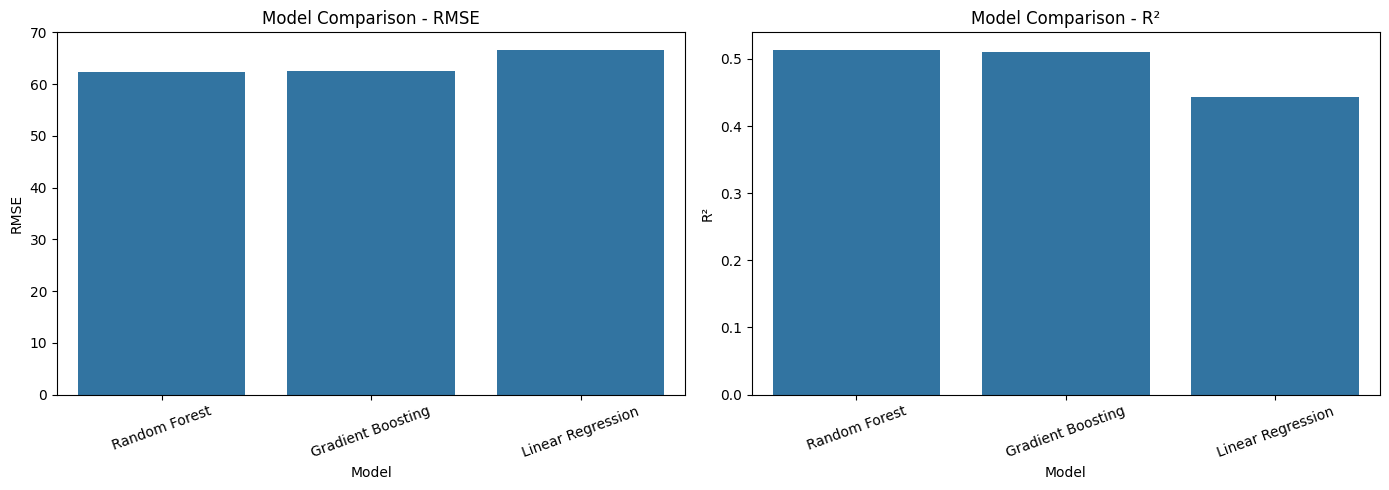

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("Model Comparison - RMSE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="Model", y="R²", ax=axes[1])
axes[1].set_title("Model Comparison - R²")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on RMSE:", best_model_name)
print("\nPerformance:")
display(results_df.iloc[[0]])

Best model based on RMSE: Random Forest

Performance:


,Model,MAE,RMSE,R²
1,Random Forest,40.527894,62.334073,0.514024


## Hyperparameter Tuning

The best-performing model from the initial comparison is selected for
hyperparameter tuning.

Grid Search with cross-validation is used to identify a better combination
of model parameters while avoiding selection based on a single validation
split.

In [32]:
from sklearn.model_selection import GridSearchCV

if best_model_name == "Random Forest":
    
    param_grid = {
        "model__n_estimators": [100, 150],
        "model__max_depth": [10, 15, 20],
        "model__min_samples_split": [2, 5]
    }

elif best_model_name == "Gradient Boosting":
    
    param_grid = {
        "model__n_estimators": [100, 150],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    }

else:
    
    param_grid = {
        "model__fit_intercept": [True, False]
    }

grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation RMSE:")
print(-grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters:
{'model__max_depth': 15, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best cross-validation RMSE:
62.620171597281605


In [33]:
final_model = grid_search.best_estimator_

print("Final tuned model:")
print(final_model)

Final tuned model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365',
                                                   'last_review_year',
                              

In [34]:
# Predictions on test data
y_pred = final_model.predict(X_test)

# Calculate metrics
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("=" * 40)
print(f"MAE  : {final_mae:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

Final Model Performance
MAE  : 40.50
RMSE : 62.24
R²   : 0.5154


In [35]:
# Training predictions
y_train_pred = final_model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Test metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R²": [train_r2, test_r2]
})

display(comparison)

,Dataset,MAE,RMSE,R²
0,Training,29.594514,43.875497,0.763458
1,Testing,40.495220,62.243103,0.515441


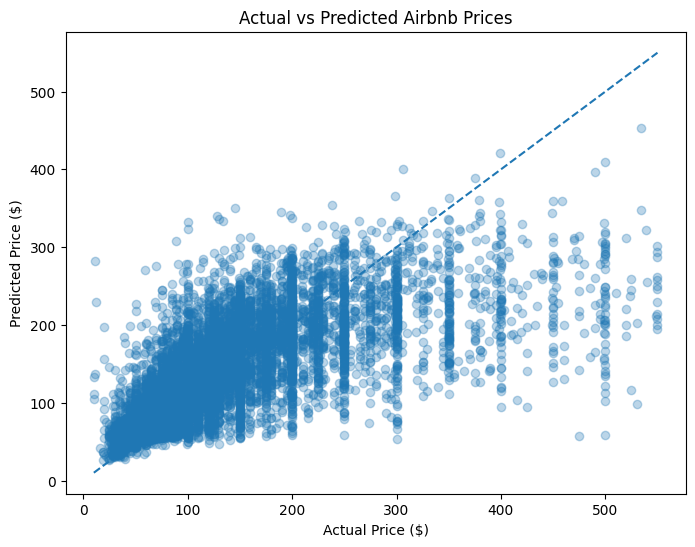

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

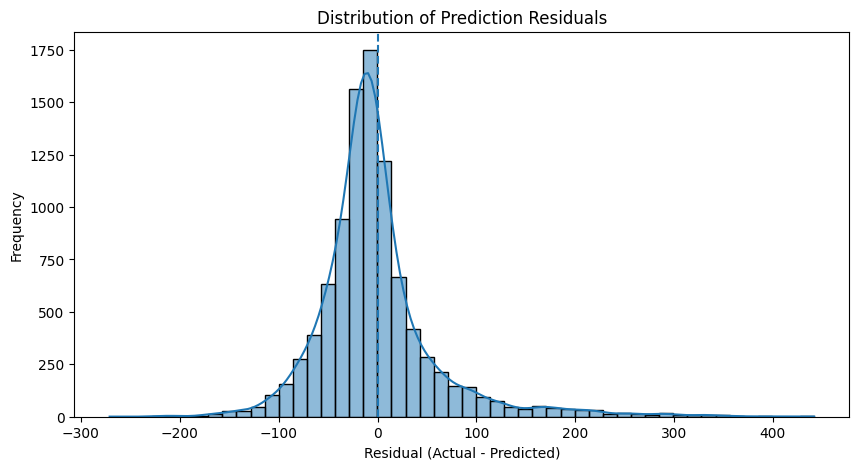

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

In [38]:
import joblib

# Save the complete preprocessing + model pipeline
joblib.dump(final_model, "airbnb_price_model.pkl")

print("Model saved successfully as: airbnb_price_model.pkl")

Model saved successfully as: airbnb_price_model.pkl


ORIGINAL DATASET
Shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Duplicate rows: 0

Rows removed because of invalid price: 11
99th percentile price: 799.0
Rows removed as extreme price outliers: 474
Maximum price after treatment: 799

FINAL MODELING DATA
Number of observations: 48410
Number of features: 13

Selected features:
1. neighbourhood_group
2. neighbourhood
3. latitude
4. longitude
5. distance_from_center
6. room_type
7. neighbourhood_room
8. log_minimum_nights
9. log_number_of_reviews
10. log_reviews_per_month
11. log_calculated_host_listings_count
12. availability_ratio
13. has_review

Training samples: 38728
Testing samples : 9682

Training: Ridge Regression

Training: Random Forest

Training: Extra Trees

BASELINE MODEL COMPARISON
          

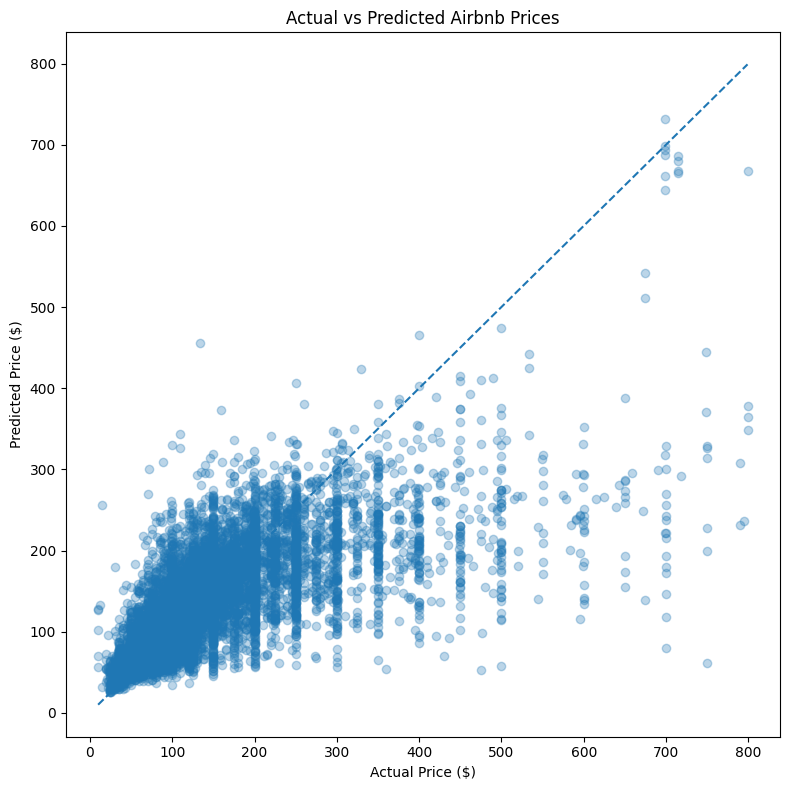

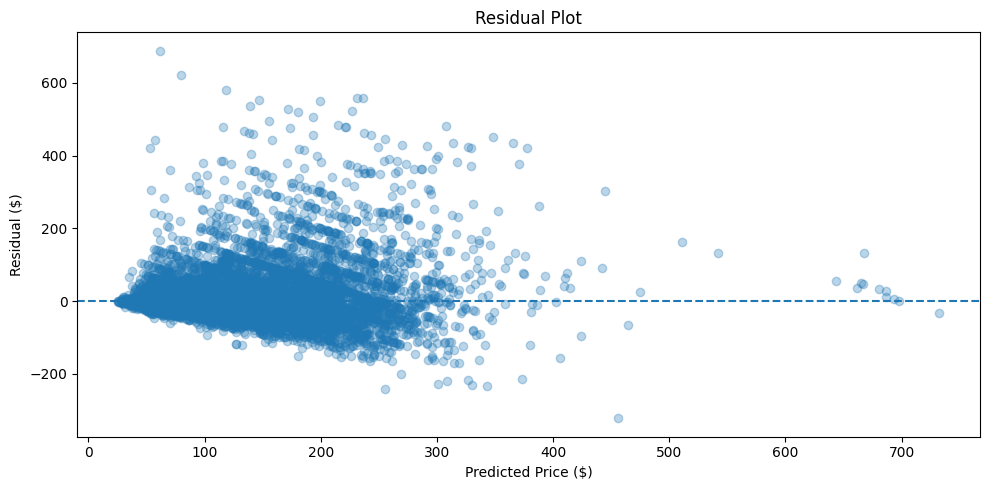


MODEL SAVED
Saved to: airbnb_price_prediction_final.pkl

Predictions from the saved model:
$122.52
$182.09
$60.67
$54.22
$35.89

TASK 1 + TASK 2 COMPLETED
Final model: Tuned Random Forest
Test MAE : $41.79
Test RMSE: $72.66
Test R2  : 0.5148
Model file: airbnb_price_prediction_final.pkl


In [39]:
"""
Airbnb Price Prediction - Task 1 + Task 2
-----------------------------------------
This script:
1. Loads the Airbnb dataset.
2. Cleans the data.
3. Creates engineered features.
4. Handles missing values through a preprocessing pipeline.
5. Compares Ridge, Random Forest and Extra Trees regression.
6. Tunes Random Forest using cross-validation.
7. Checks overfitting.
8. Saves the final model for Task 3 (Streamlit/Gradio).

IMPORTANT:
- Change DATA_PATH below to the location of your CSV file.
- If you already have a cleaned dataframe called `df` in a notebook,
  the equivalent Task 2 starts from the "FEATURE ENGINEERING" section.
"""

# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DATA
# ============================================================

# CHANGE THIS PATH IF REQUIRED
DATA_PATH = "AB_NYC_2019.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Change DATA_PATH to the location of your Airbnb CSV file."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. BASIC CLEANING
# ============================================================

# Remove exact duplicate rows
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

df = df.drop_duplicates().copy()


# ------------------------------------------------------------
# Remove irrelevant identifier / free-text columns
# ------------------------------------------------------------

columns_to_drop = [
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review"
]

# Keep last_review temporarily because we use it to create
# has_review, year and month.
columns_to_drop_without_date = [
    "id",
    "host_id",
    "name",
    "host_name"
]

df = df.drop(
    columns=[
        c for c in columns_to_drop_without_date
        if c in df.columns
    ],
    errors="ignore"
)


# ============================================================
# 3. DATE FEATURE ENGINEERING
# ============================================================

if "last_review" in df.columns:

    df["last_review"] = pd.to_datetime(
        df["last_review"],
        errors="coerce"
    )

    # A listing has a review if last_review is available
    df["has_review"] = (
        df["last_review"].notna()
    ).astype(int)

    # These are optional exploratory features.
    # They are NOT used in the final feature set because
    # they showed very weak relationship with price.
    df["last_review_year"] = (
        df["last_review"].dt.year
    )

    df["last_review_month"] = (
        df["last_review"].dt.month
    )

else:

    df["has_review"] = 0


# ============================================================
# 4. TARGET CLEANING
# ============================================================

# Ensure price is numeric
df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

# Remove missing and zero/negative prices
before_price_cleaning = len(df)

df = df[
    df["price"].notna() &
    (df["price"] > 0)
].copy()

print("\nRows removed because of invalid price:",
      before_price_cleaning - len(df))


# ------------------------------------------------------------
# IMPORTANT:
# Calculate the percentile ONCE.
# Do not rerun this filtering cell on an already filtered df.
# ------------------------------------------------------------

price_upper_limit = df["price"].quantile(0.99)

print("99th percentile price:", price_upper_limit)

before_outlier = len(df)

df = df[
    df["price"] <= price_upper_limit
].copy()

print(
    "Rows removed as extreme price outliers:",
    before_outlier - len(df)
)

print("Maximum price after treatment:",
      df["price"].max())


# ============================================================
# 5. NUMERICAL CLEANING
# ============================================================

numeric_raw_columns = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in numeric_raw_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# Remove impossible negative values.
# Missing values are NOT manually filled here;
# the modeling pipeline handles them using median imputation.

for col in [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]:

    if col in df.columns:

        df.loc[
            df[col] < 0,
            col
        ] = np.nan


# Availability must be between 0 and 365
if "availability_365" in df.columns:

    df["availability_365"] = df[
        "availability_365"
    ].clip(
        lower=0,
        upper=365
    )


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# Log transformations
# ------------------------------------------------------------
# These variables are strongly right-skewed.
# log1p(x) = log(1+x), so zero values are safe.

log_source_columns = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for col in log_source_columns:

    if col not in df.columns:
        raise ValueError(
            f"Required column missing: {col}"
        )

    # Temporary fill only for creating the log feature.
    # The final raw feature is not used in the model.
    values = df[col].fillna(0).clip(lower=0)

    df[
        "log_" + col
    ] = np.log1p(values)


# ------------------------------------------------------------
# Availability ratio
# ------------------------------------------------------------

if "availability_365" in df.columns:

    df["availability_ratio"] = (
        df["availability_365"] / 365.0
    )


# ------------------------------------------------------------
# Distance from approximate NYC centre
# ------------------------------------------------------------

if (
    "latitude" in df.columns
    and
    "longitude" in df.columns
):

    reference_lat = 40.7128
    reference_lon = -74.0060

    df["distance_from_center"] = np.sqrt(
        (df["latitude"] - reference_lat) ** 2
        +
        (df["longitude"] - reference_lon) ** 2
    )


# ------------------------------------------------------------
# Neighbourhood × room type interaction
# ------------------------------------------------------------

if (
    "neighbourhood_group" in df.columns
    and
    "room_type" in df.columns
):

    df["neighbourhood_room"] = (
        df["neighbourhood_group"].astype(str)
        + "_"
        + df["room_type"].astype(str)
    )


# ============================================================
# 7. FINAL FEATURE SELECTION
# ============================================================

features = [

    # Location
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "distance_from_center",

    # Room information
    "room_type",
    "neighbourhood_room",

    # Skewed numerical variables after log transformation
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",

    # Availability
    "availability_ratio",

    # Review information
    "has_review"
]

target = "price"


missing_features = [
    col
    for col in features
    if col not in df.columns
]

if missing_features:

    raise ValueError(
        "The following selected features are missing:\n"
        + str(missing_features)
    )

X = df[features].copy()
y = df[target].copy()

print("\n" + "=" * 70)
print("FINAL MODELING DATA")
print("=" * 70)

print("Number of observations:", len(X))
print("Number of features:", len(features))

print("\nSelected features:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")


# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 9. DEFINE FEATURE TYPES
# ============================================================

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "neighbourhood_room"
]

numerical_features = [
    "latitude",
    "longitude",
    "distance_from_center",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",
    "availability_ratio",
    "has_review"
]


# ============================================================
# 10. PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 11. TARGET TRANSFORMATION
# ============================================================

# Airbnb prices are strongly right-skewed.
# log1p reduces the effect of very large prices.
# Predictions are automatically converted back using expm1.

target_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    validate=False
)


# ============================================================
# 12. CREATE BASELINE MODELS
# ============================================================

models = {

    "Ridge Regression": Ridge(
        alpha=10.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
}


model_pipelines = {}

for name, model in models.items():

    base_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    model_pipelines[name] = (
        TransformedTargetRegressor(
            regressor=base_pipeline,
            transformer=target_transformer
        )
    )


# ============================================================
# 13. TRAIN AND COMPARE BASELINE MODELS
# ============================================================

results = []

for name, model in model_pipelines.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })


results_df = pd.DataFrame(
    results
).sort_values(
    by="Test RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)

print(results_df.to_string(index=False))


# ============================================================
# 14. CROSS-VALIDATION
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in model_pipelines.items():

    print("\nCross-validating:", name)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean()
    })


cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    by="CV RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

print(cv_results_df.to_string(index=False))


# ============================================================
# 15. HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=target_transformer
)


param_distributions = {

    "regressor__model__n_estimators": [
        150,
        200,
        300
    ],

    "regressor__model__max_depth": [
        10,
        15,
        20,
        None
    ],

    "regressor__model__min_samples_split": [
        2,
        5,
        10
    ],

    "regressor__model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "regressor__model__max_features": [
        "sqrt",
        "log2",
        0.5
    ]
}


rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print("\n" + "=" * 70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

rf_search.fit(
    X_train,
    y_train
)


print("\nBest parameters:")

for parameter, value in rf_search.best_params_.items():
    print(
        f"{parameter}: {value}"
    )


print(
    "\nBest CV RMSE:",
    -rf_search.best_score_
)


# ============================================================
# 16. EVALUATE TUNED RANDOM FOREST
# ============================================================

final_model = rf_search.best_estimator_

final_train_pred = final_model.predict(
    X_train
)

final_test_pred = final_model.predict(
    X_test
)


final_train_mae = mean_absolute_error(
    y_train,
    final_train_pred
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)


final_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        final_train_pred
    )
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)


final_train_r2 = r2_score(
    y_train,
    final_train_pred
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)


print("\n" + "=" * 70)
print("FINAL TUNED RANDOM FOREST")
print("=" * 70)

print(
    f"Train MAE  : ${final_train_mae:.2f}"
)

print(
    f"Test MAE   : ${final_test_mae:.2f}"
)

print(
    f"Train RMSE : ${final_train_rmse:.2f}"
)

print(
    f"Test RMSE  : ${final_test_rmse:.2f}"
)

print(
    f"Train R2   : {final_train_r2:.4f}"
)

print(
    f"Test R2    : {final_test_r2:.4f}"
)


# ============================================================
# 17. OVERFITTING CHECK
# ============================================================

r2_gap = (
    final_train_r2
    -
    final_test_r2
)


print("\n" + "=" * 70)
print("OVERFITTING CHECK")
print("=" * 70)

print(
    f"Train R2 : {final_train_r2:.4f}"
)

print(
    f"Test R2  : {final_test_r2:.4f}"
)

print(
    f"R2 gap   : {r2_gap:.4f}"
)


if r2_gap > 0.20:

    print(
        "Result: Moderate/significant overfitting may be present."
    )

elif r2_gap > 0.10:

    print(
        "Result: Some overfitting may be present."
    )

else:

    print(
        "Result: No major overfitting detected."
    )


# ============================================================
# 18. FINAL MODEL COMPARISON TABLE
# ============================================================

final_comparison = results_df.copy()

tuned_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Train MAE": final_train_mae,
    "Test MAE": final_test_mae,
    "Train RMSE": final_train_rmse,
    "Test RMSE": final_test_rmse,
    "Train R2": final_train_r2,
    "Test R2": final_test_r2
}])


final_comparison = pd.concat(
    [
        final_comparison,
        tuned_row
    ],
    ignore_index=True
)


final_comparison = final_comparison.sort_values(
    by="Test RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    final_comparison.to_string(index=False)
)


best_model_name = (
    final_comparison.iloc[0]["Model"]
)

print(
    "\nBest model based on test RMSE:",
    best_model_name
)


# ============================================================
# 19. ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.3
)

minimum_value = min(
    y_test.min(),
    final_test_pred.min()
)

maximum_value = max(
    y_test.max(),
    final_test_pred.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.tight_layout()
plt.show()


# ============================================================
# 20. RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_test -
    final_test_pred
)

plt.figure(
    figsize=(10, 5)
)

plt.scatter(
    final_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


# ============================================================
# 21. SAVE FINAL MODEL
# ============================================================

MODEL_PATH = "airbnb_price_prediction_final.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    f"Saved to: {MODEL_PATH}"
)


# ============================================================
# 22. SAVE MODEL RESULTS
# ============================================================

final_comparison.to_csv(
    "airbnb_model_comparison.csv",
    index=False
)


pd.DataFrame({
    "Metric": [
        "Test MAE",
        "Test RMSE",
        "Test R2",
        "Train R2",
        "R2 Gap"
    ],
    "Value": [
        final_test_mae,
        final_test_rmse,
        final_test_r2,
        final_train_r2,
        r2_gap
    ]
}).to_csv(
    "airbnb_final_metrics.csv",
    index=False
)


pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": final_test_pred
}).assign(
    Absolute_Error=lambda x:
        abs(
            x["Actual_Price"]
            -
            x["Predicted_Price"]
        )
).to_csv(
    "airbnb_test_predictions.csv",
    index=False
)


# ============================================================
# 23. TEST SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    MODEL_PATH
)

saved_model_predictions = loaded_model.predict(
    X_test.iloc[:5]
)

print("\nPredictions from the saved model:")

for prediction in saved_model_predictions:
    print(
        f"${prediction:.2f}"
    )


print("\n" + "=" * 70)
print("TASK 1 + TASK 2 COMPLETED")
print("=" * 70)
print("Final model:", best_model_name)
print(f"Test MAE : ${final_test_mae:.2f}")
print(f"Test RMSE: ${final_test_rmse:.2f}")
print(f"Test R2  : {final_test_r2:.4f}")
print("Model file:", MODEL_PATH)
